# <center> Hands on lab <center>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv("sleep_doomscrolling_habits.csv")
df

,respondent_id,age,bedtime_screen_time_minutes,total_daily_screen_time_hours,doomscroll_sessions_per_night,avg_doomscroll_session_minutes,sleep_hours_per_night,sleep_latency_minutes,number_of_night_wakeups,caffeine_intake_mg_per_day,...,occupation_status,country_region,primary_device_used_at_night,bedtime_routine_type,uses_night_mode,keeps_phone_in_bedroom,consumes_negative_news_content,uses_sleep_tracking_app,doomscroller,sleep_quality_category
0,D30000,22,13.0,1.85,2,5.4,8.1,19.0,2,155.0,...,Unemployed,Germany,Tablet,Meditation/Journaling,Yes,Yes,Yes,No,Yes,Good
1,D30001,18,90.0,3.61,3,29.6,7.0,31.0,3,82.0,...,Student,India,Smartphone,Meditation/Journaling,No,Yes,Yes,No,Yes,Poor
2,D30002,37,51.0,5.15,3,15.5,7.1,24.0,2,49.0,...,Student,India,Laptop,Reading,No,Yes,No,Yes,Yes,Fair
3,D30003,27,53.0,3.74,0,51.4,8.4,35.0,0,42.0,...,NaN,United States,Smartphone,No Fixed Routine,No,Yes,Yes,No,No,Fair
4,D30004,17,67.0,6.09,2,32.2,7.2,19.0,1,76.0,...,Employed Part-time,United States,Smartphone,Watching Videos,No,No,No,No,No,Fair
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,D30995,26,85.0,3.56,4,25.4,7.6,34.0,1,169.0,...,Student,India,Tablet,Meditation/Journaling,No,Yes,Yes,Yes,Yes,Poor
996,D30996,23,3.0,1.10,1,10.7,7.5,31.0,1,34.0,...,Student,United States,Smartphone,Scrolling Social Media,No,Yes,No,No,No,Fair
997,D30997,15,28.0,4.38,1,30.6,9.2,20.0,0,100.0,...,Employed Full-time,United States,Smartphone,Scrolling Social Media,No,Yes,No,No,No,Good
998,D30998,22,23.0,1.84,0,27.9,6.9,41.0,2,45.0,...,Student,India,Tablet,Watching Videos,No,Yes,Yes,Yes,No,Fair


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   respondent_id                   1000 non-null   str    
 1   age                             1000 non-null   int64  
 2   bedtime_screen_time_minutes     1000 non-null   float64
 3   total_daily_screen_time_hours   1000 non-null   float64
 4   doomscroll_sessions_per_night   1000 non-null   int64  
 5   avg_doomscroll_session_minutes  1000 non-null   float64
 6   sleep_hours_per_night           1000 non-null   float64
 7   sleep_latency_minutes           1000 non-null   float64
 8   number_of_night_wakeups         1000 non-null   int64  
 9   caffeine_intake_mg_per_day      950 non-null    float64
 10  anxiety_score                   1000 non-null   int64  
 11  stress_score                    1000 non-null   int64  
 12  sleep_quality_score             960 non-null  

In [4]:
df.isnull().sum()

respondent_id                      0
age                                0
bedtime_screen_time_minutes        0
total_daily_screen_time_hours      0
doomscroll_sessions_per_night      0
avg_doomscroll_session_minutes     0
sleep_hours_per_night              0
sleep_latency_minutes              0
number_of_night_wakeups            0
caffeine_intake_mg_per_day        50
anxiety_score                      0
stress_score                       0
sleep_quality_score               40
daytime_fatigue_score              0
number_of_news_apps_used           0
phone_checks_per_night             0
exercise_minutes_per_day          50
days_since_last_digital_detox      0
weekly_sleep_debt_hours            0
gender                             0
occupation_status                 30
country_region                     0
primary_device_used_at_night      30
bedtime_routine_type              20
uses_night_mode                    0
keeps_phone_in_bedroom             0
consumes_negative_news_content     0
u

In [5]:
df.fillna(df.mean(numeric_only=True), inplace=True)

categorical_null_cols = ['occupation_status', 'primary_device_used_at_night', 'bedtime_routine_type']
for col in categorical_null_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [6]:
df.isnull().sum()

respondent_id                     0
age                               0
bedtime_screen_time_minutes       0
total_daily_screen_time_hours     0
doomscroll_sessions_per_night     0
avg_doomscroll_session_minutes    0
sleep_hours_per_night             0
sleep_latency_minutes             0
number_of_night_wakeups           0
caffeine_intake_mg_per_day        0
anxiety_score                     0
stress_score                      0
sleep_quality_score               0
daytime_fatigue_score             0
number_of_news_apps_used          0
phone_checks_per_night            0
exercise_minutes_per_day          0
days_since_last_digital_detox     0
weekly_sleep_debt_hours           0
gender                            0
occupation_status                 0
country_region                    0
primary_device_used_at_night      0
bedtime_routine_type              0
uses_night_mode                   0
keeps_phone_in_bedroom            0
consumes_negative_news_content    0
uses_sleep_tracking_app     

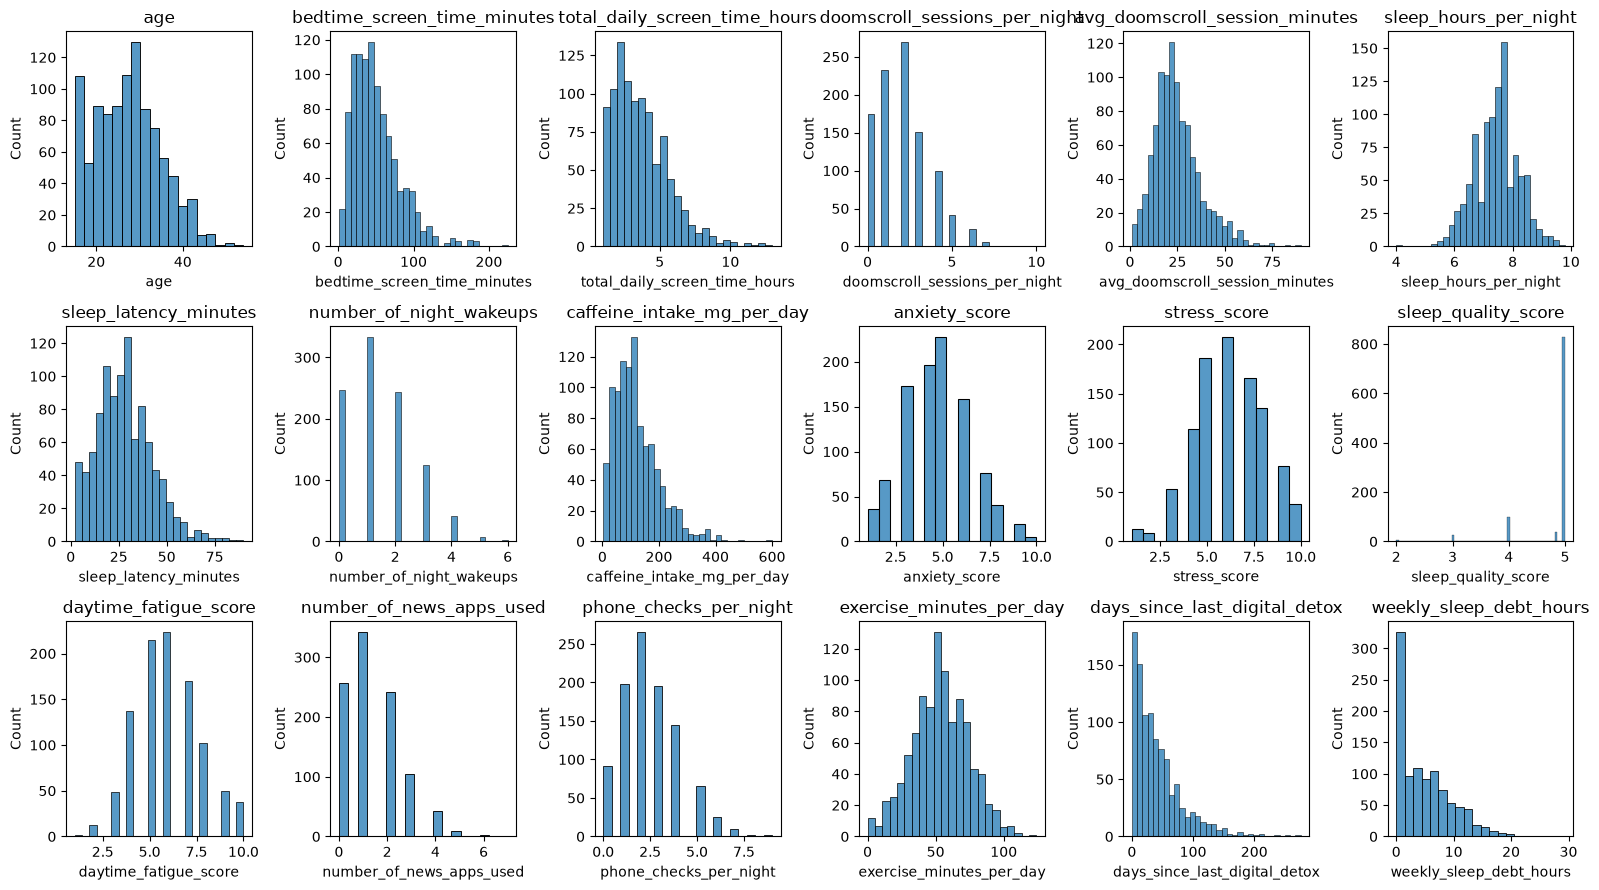

In [7]:
numeric_columns = ["age","bedtime_screen_time_minutes",
"total_daily_screen_time_hours","doomscroll_sessions_per_night","avg_doomscroll_session_minutes",
"sleep_hours_per_night","sleep_latency_minutes","number_of_night_wakeups","caffeine_intake_mg_per_day",
"anxiety_score","stress_score","sleep_quality_score","daytime_fatigue_score","number_of_news_apps_used",
"phone_checks_per_night","exercise_minutes_per_day","days_since_last_digital_detox","weekly_sleep_debt_hours"]

n_cols = 6
n_rows = -(-len(numeric_columns) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for ax, col in zip(axes, numeric_columns):
    sns.histplot(df, x=col, ax=ax)
    ax.set_title(f"{col}")

plt.tight_layout()
plt.show()

In [8]:
def find_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return dataframe[(dataframe[column] < lower) | (dataframe[column] > upper)]

for col in numeric_columns:
    found = find_outliers_iqr(df, col)
    print(f"{col}: {len(found)} outlier(s) found")
    if len(found) > 0:3333
    print(found[[col]].to_string())
    print()

age: 3 outlier(s) found
     age
173   50
274   50
704   54

bedtime_screen_time_minutes: 24 outlier(s) found
     bedtime_screen_time_minutes
33                         128.0
41                         158.0
42                         173.0
49                         152.0
88                         128.0
136                        143.0
139                        184.0
219                        161.0
235                        171.0
285                        125.0
308                        148.0
532                        172.0
537                        184.0
609                        127.0
621                        171.0
683                        149.0
700                        149.0
746                        128.0
778                        183.0
857                        128.0
882                        147.0
889                        152.0
961                        225.0
982                        162.0

total_daily_screen_time_hours: 20 outlier(s) found
     total_da

In [9]:
summary = []
for col in numeric_columns:
    found = find_outliers_iqr(df, col)
    summary.append({'column': col, 'n_outliers': len(found), 'pct': len(found)/len(df)*100})
pd.DataFrame(summary).sort_values('n_outliers', ascending=False)

,column,n_outliers,pct
11,sleep_quality_score,170,17.0
7,number_of_night_wakeups,52,5.2
16,days_since_last_digital_detox,46,4.6
4,avg_doomscroll_session_minutes,36,3.6
8,caffeine_intake_mg_per_day,26,2.6
1,bedtime_screen_time_minutes,24,2.4
2,total_daily_screen_time_hours,20,2.0
6,sleep_latency_minutes,15,1.5
14,phone_checks_per_night,14,1.4
3,doomscroll_sessions_per_night,9,0.9


###  Step 1: Produce scatter plots and grouped box plots for the most important variable pairs in the dataset.


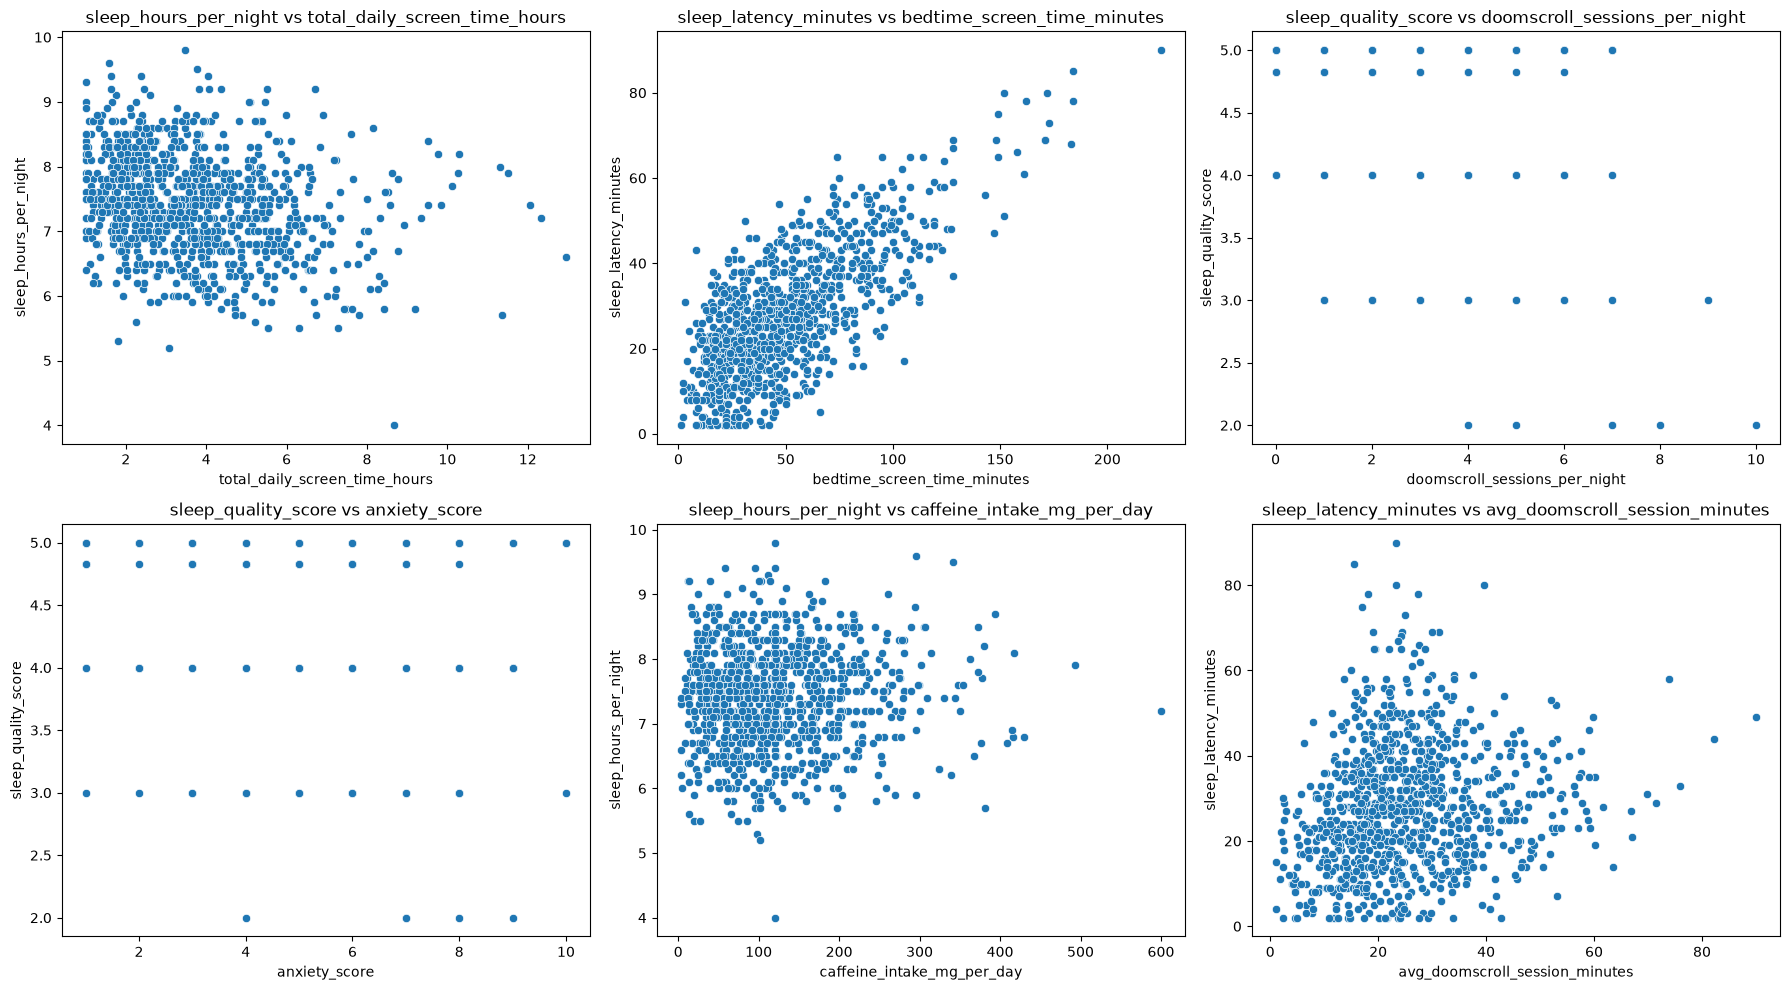

In [10]:
important_pairs = [
    ('total_daily_screen_time_hours', 'sleep_hours_per_night'),
    ('bedtime_screen_time_minutes', 'sleep_latency_minutes'),
    ('doomscroll_sessions_per_night', 'sleep_quality_score'),
    ('anxiety_score', 'sleep_quality_score'),
    ('caffeine_intake_mg_per_day', 'sleep_hours_per_night'),
    ('avg_doomscroll_session_minutes', 'sleep_latency_minutes')
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, (x, y) in enumerate(important_pairs):
    sns.scatterplot(data=df, x=x, y=y, ax=axes[i])
    axes[i].set_title(f"{y} vs {x}")
plt.tight_layout()
plt.show()

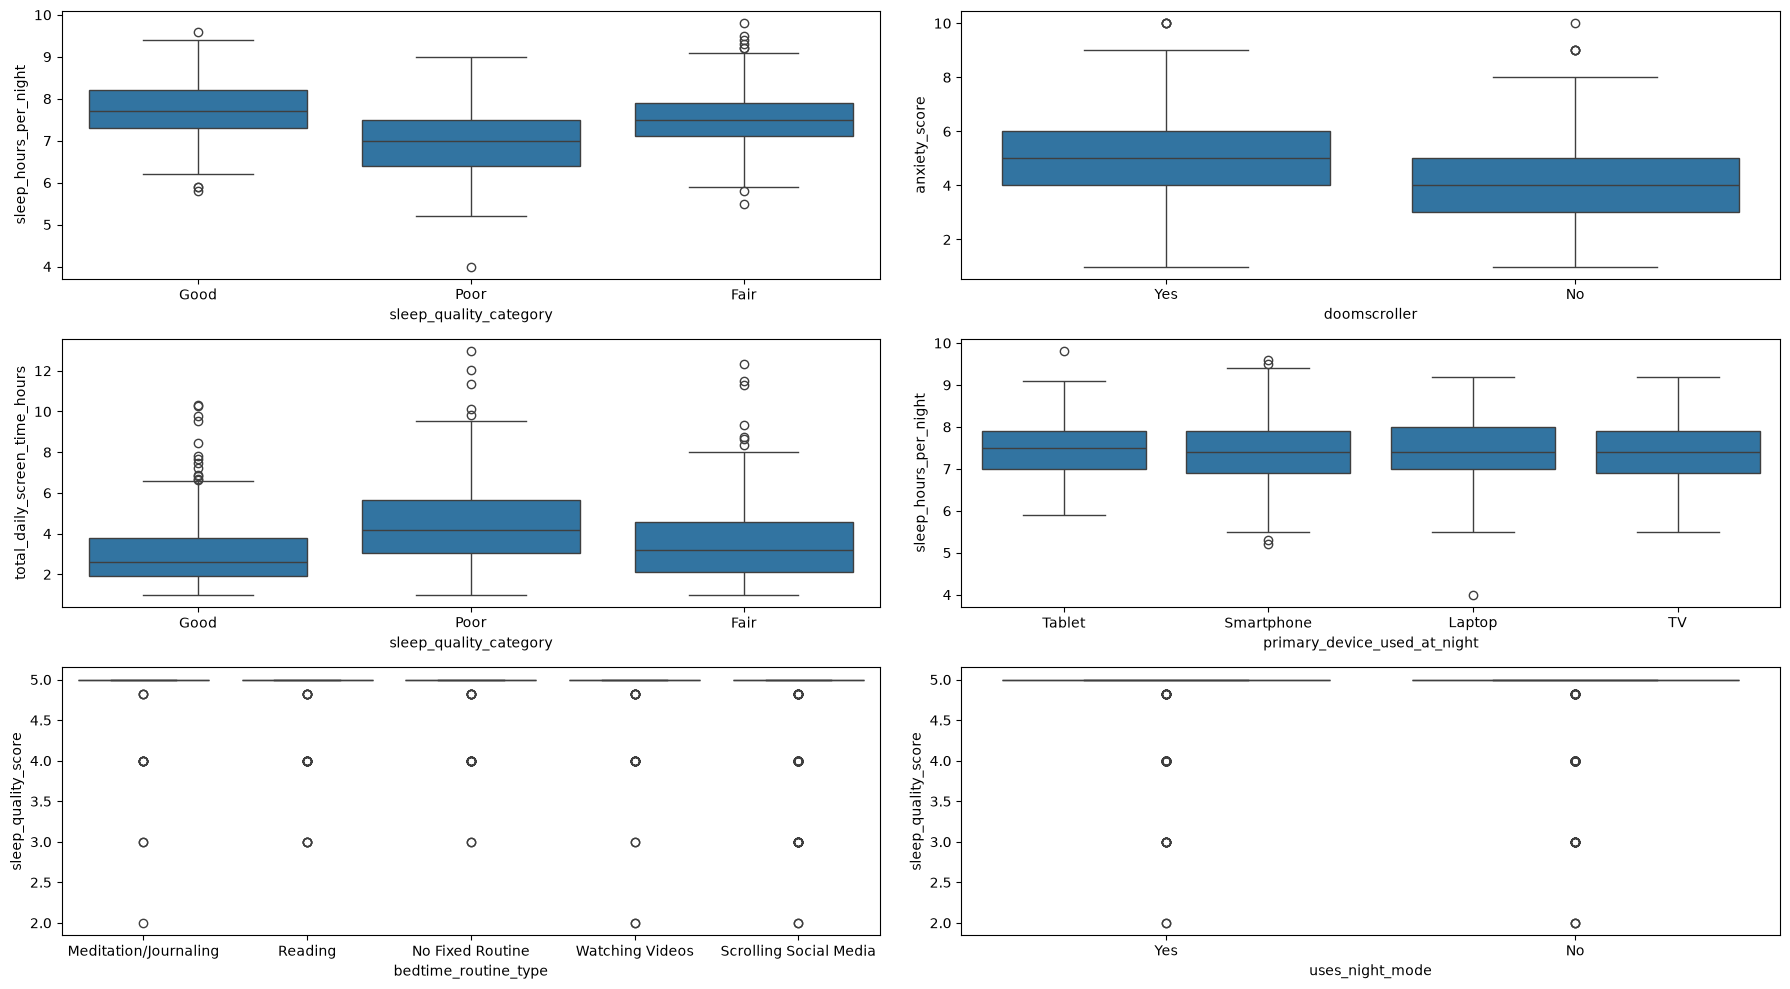

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(18, 10))
axes = axes.flatten()

sns.boxplot(data=df, x='sleep_quality_category', y='sleep_hours_per_night', ax=axes[0])
sns.boxplot(data=df, x='doomscroller', y='anxiety_score', ax=axes[1])
sns.boxplot(data=df, x='sleep_quality_category', y='total_daily_screen_time_hours', ax=axes[2])
sns.boxplot(data=df, x='primary_device_used_at_night', y='sleep_hours_per_night', ax=axes[3])
sns.boxplot(data=df, x='bedtime_routine_type', y='sleep_quality_score', ax=axes[4])
sns.boxplot(data=df, x='uses_night_mode', y='sleep_quality_score', ax=axes[5])

plt.tight_layout()
plt.show()

##  Step 2: Compute the correlation matrix and visualize it as an annotated heatmap.

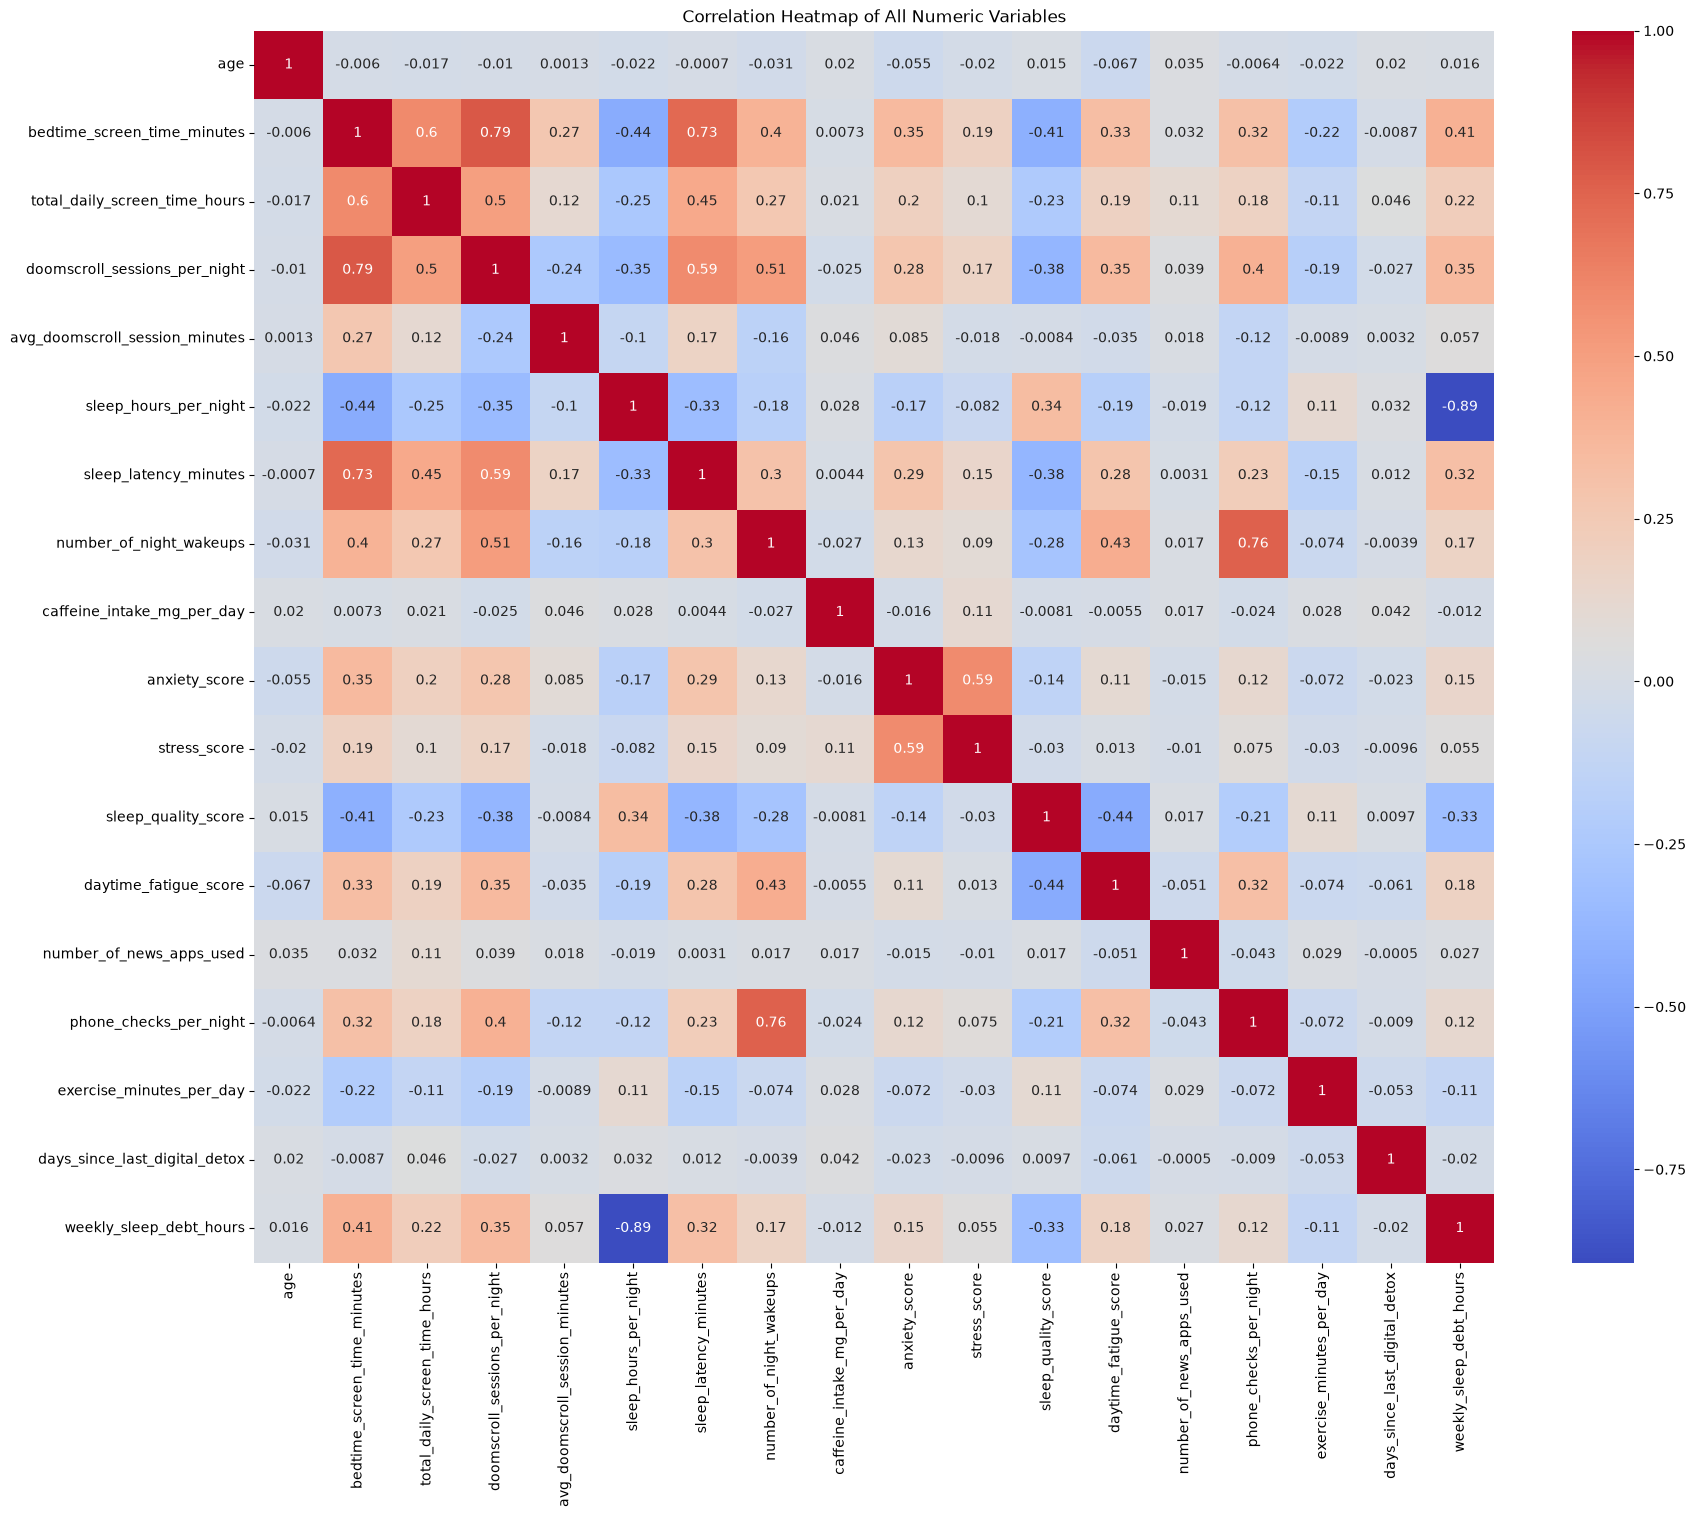

In [12]:

corr = df.corr(numeric_only=True)

plt.figure(figsize=(20, 16))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of All Numeric Variables")
plt.show()

## Step 3: Identify the two or three strongest relationships and state what they might mean for a future model.

In [13]:
corr_pairs = corr.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]
top_correlations = corr_pairs.head(5)
print("Top 5 Strongest Correlations:")
print(top_correlations)



Top 5 Strongest Correlations:
doomscroll_sessions_per_night  bedtime_screen_time_minutes      0.787583
bedtime_screen_time_minutes    doomscroll_sessions_per_night    0.787583
number_of_night_wakeups        phone_checks_per_night           0.758347
phone_checks_per_night         number_of_night_wakeups          0.758347
bedtime_screen_time_minutes    sleep_latency_minutes            0.729464
dtype: float64


#### Implications 

1. bedtime_screen_time_minutes & doomscroll_sessions_per_night show the strongest relationship in the dataset (strong positive correlation of 0.79) — if this pattern reflects a real behavioral link (e.g., screen time before bed drives doomscrolling behavior), a future model predicting sleep quality would want to treat these as a combined "pre-bed digital engagement" feature rather than using them separately, to avoid multicollinearity.

2. number_of_night_wakeups & phone_checks_per_night also show a strong relationship (0.76) — this suggests these two behaviors are tightly linked, likely measuring the same underlying pattern of sleep disruption. A future model predicting sleep quality could use just one of these variables, or combine them into a single "sleep disruption" score for simpler interpretation.

3. bedtime_screen_time_minutes & sleep_latency_minutes show a substantial correlation (0.73) — this aligns with established sleep research: more screen time before bed is associated with taking longer to fall asleep. This makes bedtime screen time a potentially powerful predictor for sleep quality models.

## Step4: Assemble the full EDA (statistics, univariate, outliers, bivariate, correlation) into one narrated  notebook.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("sleep_doomscrolling_habits.csv")

print(f"Dataset shape: {df.shape}")
print(f"Columns: {len(df.columns)} variables")
print(f"Missing values: {df.isnull().sum().sum()}")

Dataset shape: (1000, 30)
Columns: 30 variables
Missing values: 220


In [15]:
df.info()
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   respondent_id                   1000 non-null   str    
 1   age                             1000 non-null   int64  
 2   bedtime_screen_time_minutes     1000 non-null   float64
 3   total_daily_screen_time_hours   1000 non-null   float64
 4   doomscroll_sessions_per_night   1000 non-null   int64  
 5   avg_doomscroll_session_minutes  1000 non-null   float64
 6   sleep_hours_per_night           1000 non-null   float64
 7   sleep_latency_minutes           1000 non-null   float64
 8   number_of_night_wakeups         1000 non-null   int64  
 9   caffeine_intake_mg_per_day      950 non-null    float64
 10  anxiety_score                   1000 non-null   int64  
 11  stress_score                    1000 non-null   int64  
 12  sleep_quality_score             960 non-null  

,respondent_id,age,bedtime_screen_time_minutes,total_daily_screen_time_hours,doomscroll_sessions_per_night,avg_doomscroll_session_minutes,sleep_hours_per_night,sleep_latency_minutes,number_of_night_wakeups,caffeine_intake_mg_per_day,...,occupation_status,country_region,primary_device_used_at_night,bedtime_routine_type,uses_night_mode,keeps_phone_in_bedroom,consumes_negative_news_content,uses_sleep_tracking_app,doomscroller,sleep_quality_category
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,950.000000,...,970,1000,970,980,1000,1000,1000,1000,1000,1000
unique,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4,10,4,5,2,2,2,2,2,3
top,D30000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Employed Full-time,India,Smartphone,Scrolling Social Media,No,Yes,No,No,No,Good
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,373,270,701,375,576,754,538,691,524,340
mean,NaN,27.309000,50.111000,3.664670,2.037000,24.924800,7.415200,27.882000,1.412000,120.752632,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,7.495312,31.328136,1.923755,1.586237,12.487106,0.765751,14.510225,1.172019,81.978478,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,15.000000,1.000000,1.000000,0.000000,1.000000,4.000000,2.000000,0.000000,3.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,21.750000,27.000000,2.230000,1.000000,16.700000,6.900000,18.000000,1.000000,61.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,27.000000,44.000000,3.345000,2.000000,22.600000,7.400000,27.000000,1.000000,102.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,33.000000,66.000000,4.785000,3.000000,30.925000,7.900000,37.000000,2.000000,166.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df.isnull()

,respondent_id,age,bedtime_screen_time_minutes,total_daily_screen_time_hours,doomscroll_sessions_per_night,avg_doomscroll_session_minutes,sleep_hours_per_night,sleep_latency_minutes,number_of_night_wakeups,caffeine_intake_mg_per_day,...,occupation_status,country_region,primary_device_used_at_night,bedtime_routine_type,uses_night_mode,keeps_phone_in_bedroom,consumes_negative_news_content,uses_sleep_tracking_app,doomscroller,sleep_quality_category
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [17]:
df.fillna(df.mean(numeric_only=True), inplace=True)

categorical_null_cols = ['occupation_status', 'primary_device_used_at_night', 'bedtime_routine_type']
for col in categorical_null_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
df.isnull().sum()

respondent_id                     0
age                               0
bedtime_screen_time_minutes       0
total_daily_screen_time_hours     0
doomscroll_sessions_per_night     0
avg_doomscroll_session_minutes    0
sleep_hours_per_night             0
sleep_latency_minutes             0
number_of_night_wakeups           0
caffeine_intake_mg_per_day        0
anxiety_score                     0
stress_score                      0
sleep_quality_score               0
daytime_fatigue_score             0
number_of_news_apps_used          0
phone_checks_per_night            0
exercise_minutes_per_day          0
days_since_last_digital_detox     0
weekly_sleep_debt_hours           0
gender                            0
occupation_status                 0
country_region                    0
primary_device_used_at_night      0
bedtime_routine_type              0
uses_night_mode                   0
keeps_phone_in_bedroom            0
consumes_negative_news_content    0
uses_sleep_tracking_app     

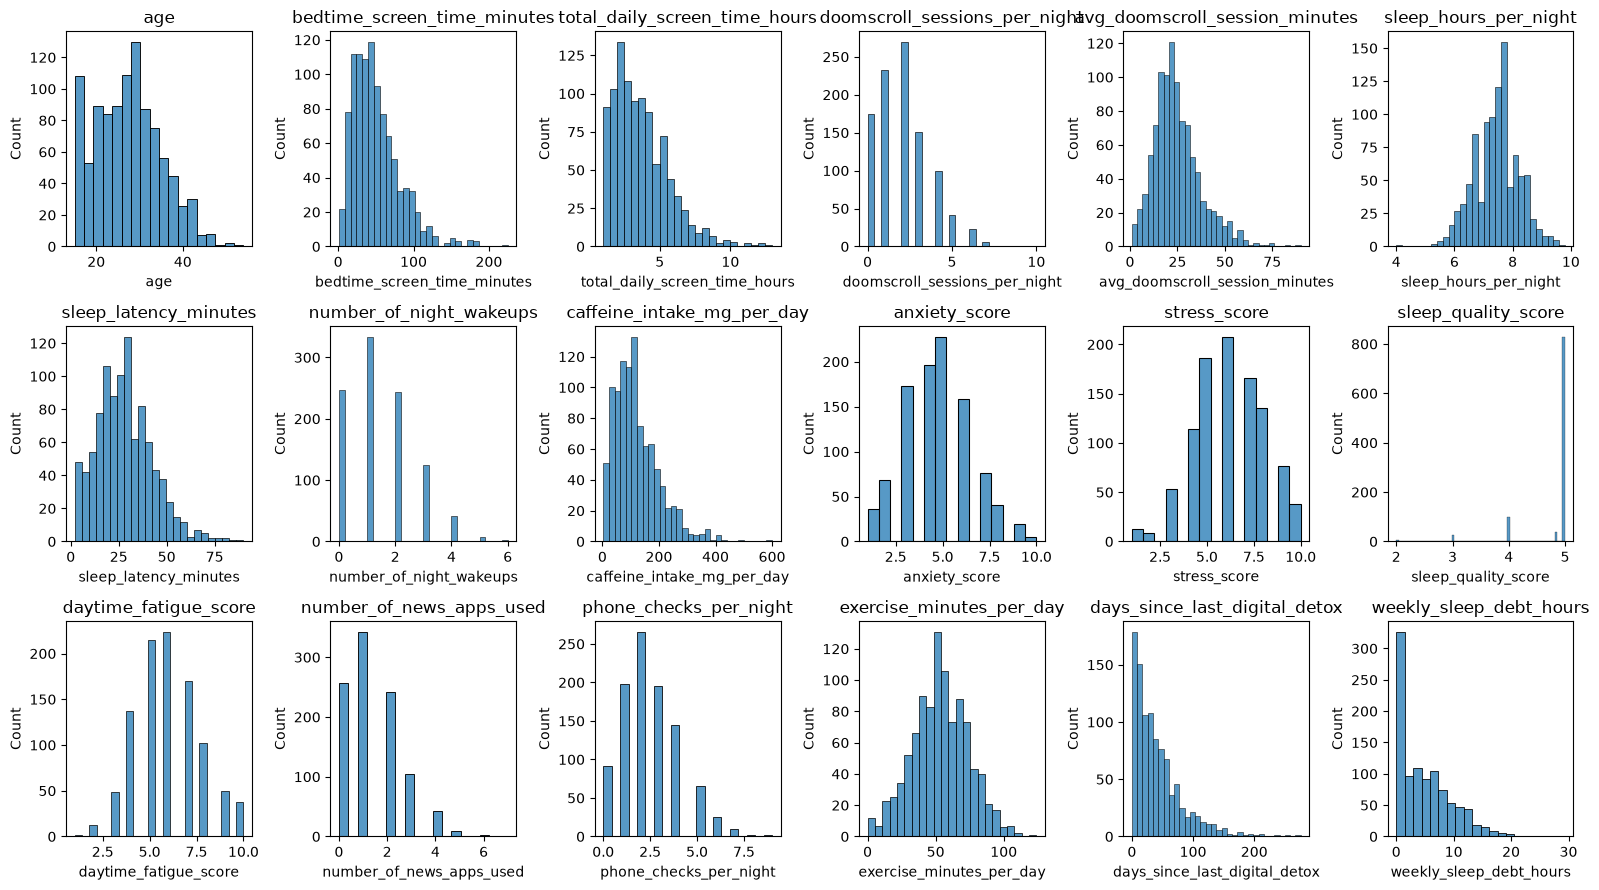

In [18]:
numeric_columns = ["age","bedtime_screen_time_minutes",
"total_daily_screen_time_hours","doomscroll_sessions_per_night","avg_doomscroll_session_minutes",
"sleep_hours_per_night","sleep_latency_minutes","number_of_night_wakeups","caffeine_intake_mg_per_day",
"anxiety_score","stress_score","sleep_quality_score","daytime_fatigue_score","number_of_news_apps_used",
"phone_checks_per_night","exercise_minutes_per_day","days_since_last_digital_detox","weekly_sleep_debt_hours"]

n_cols = 6
n_rows = -(-len(numeric_columns) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for ax, col in zip(axes, numeric_columns):
    sns.histplot(df, x=col, ax=ax)
    ax.set_title(f"{col}")

plt.tight_layout()
plt.show()

right-skewed : `days_since_last_digital_detox`, `bedtime_screen_time_minutes`, and `caffeine_intake_mg_per_day` 
 
 close to symmetric: `sleep_hours_per_night`, `stress_score`, and `exercise_minutes_per_day` are. This matters for modeling: the skewed variables are better summarized by the median than the mean, and may benefit from a log transform before being fed into a linear model.

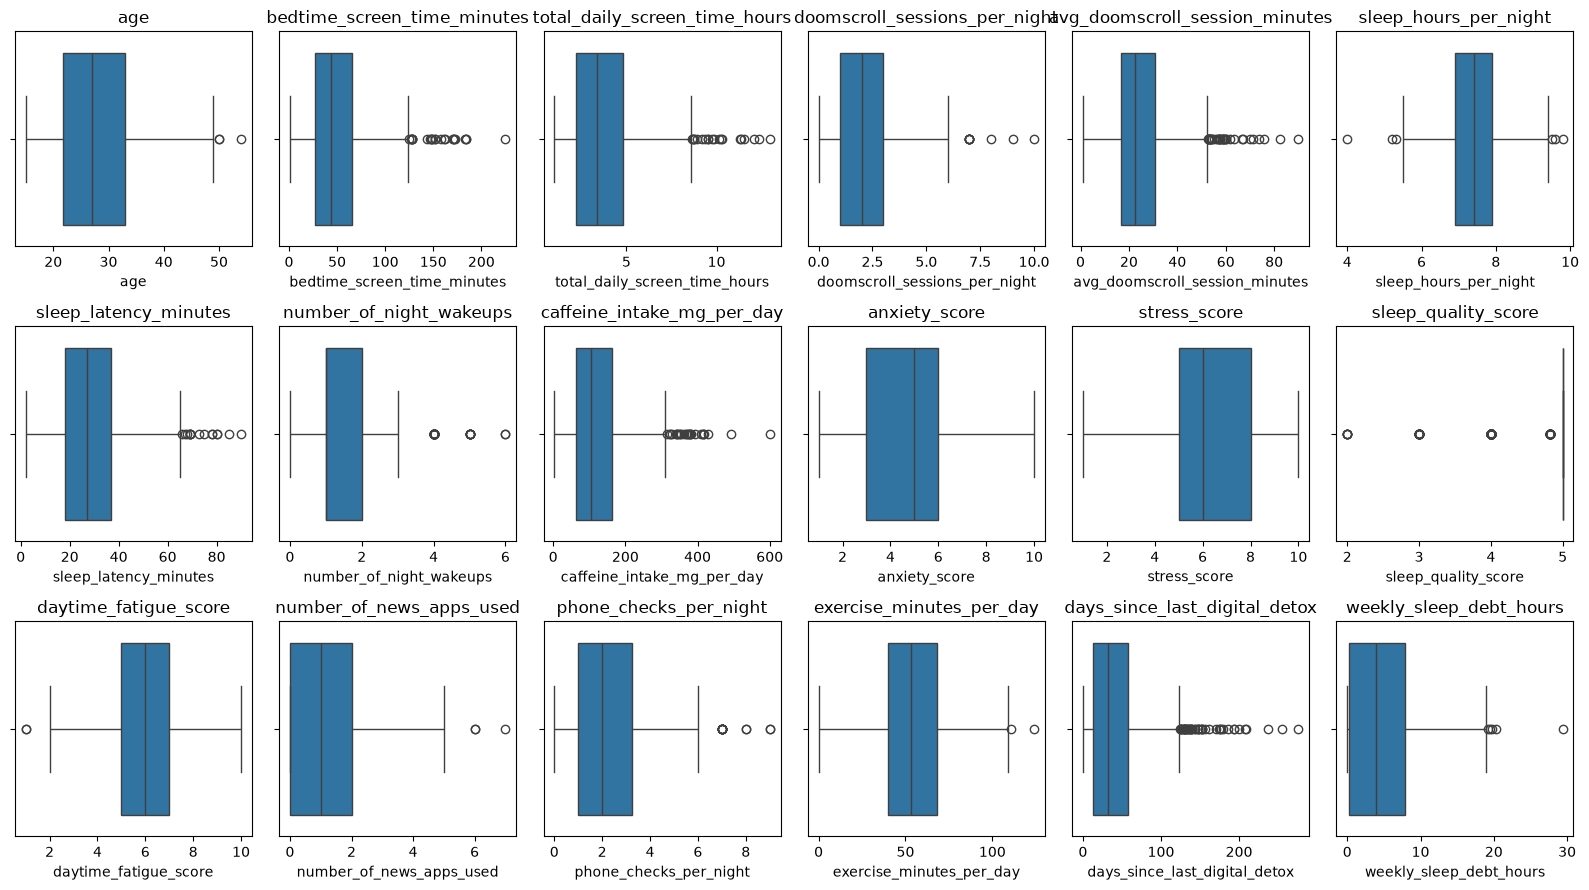

In [19]:
numeric_columns = ["age","bedtime_screen_time_minutes",
"total_daily_screen_time_hours","doomscroll_sessions_per_night","avg_doomscroll_session_minutes",
"sleep_hours_per_night","sleep_latency_minutes","number_of_night_wakeups","caffeine_intake_mg_per_day",
"anxiety_score","stress_score","sleep_quality_score","daytime_fatigue_score","number_of_news_apps_used",
"phone_checks_per_night","exercise_minutes_per_day","days_since_last_digital_detox","weekly_sleep_debt_hours"]

n_cols = 6
n_rows = -(-len(numeric_columns) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for ax, col in zip(axes, numeric_columns):
    sns.boxplot(df, x=col, ax=ax)
    ax.set_title(f"{col}")

plt.tight_layout()
plt.show()

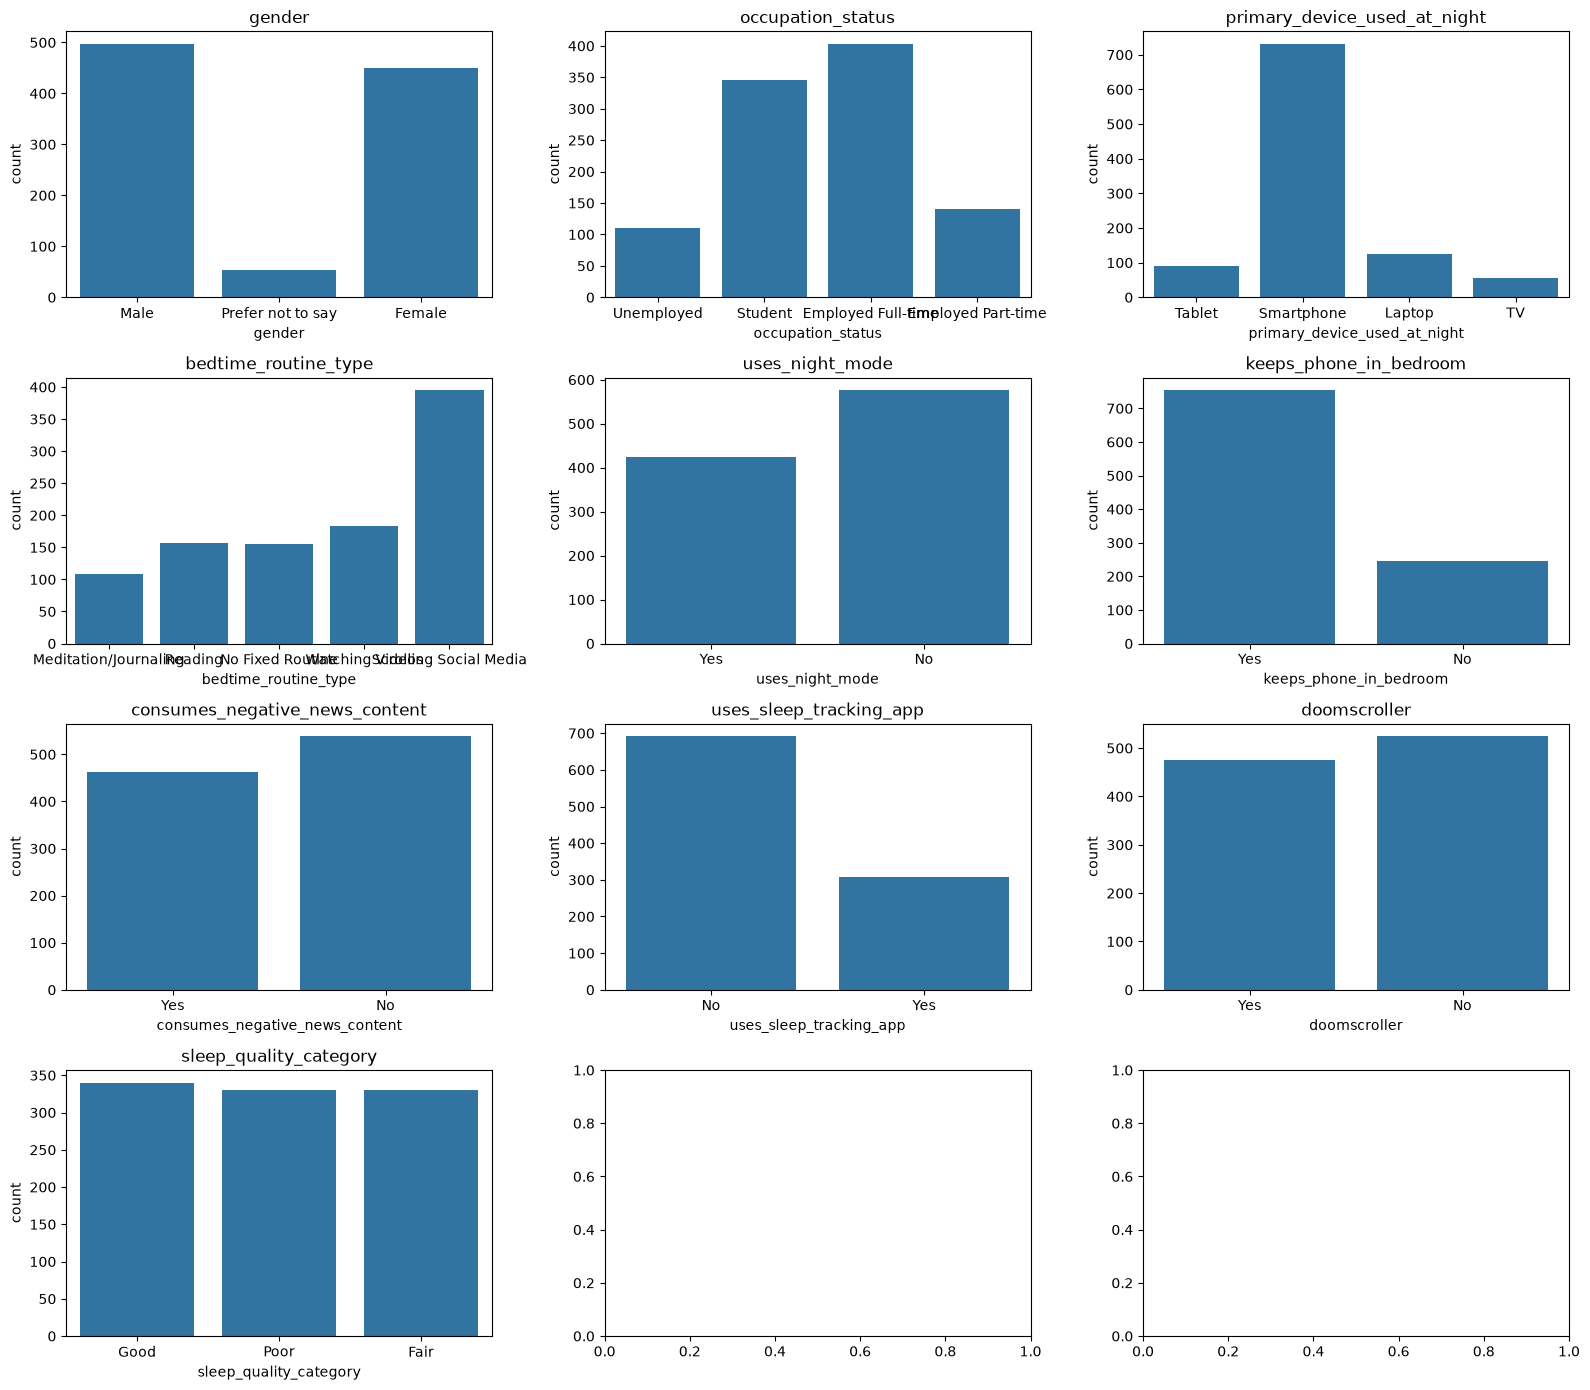

In [20]:
categorical_columns = ["gender", "occupation_status", "primary_device_used_at_night",
                       "bedtime_routine_type", "uses_night_mode", "keeps_phone_in_bedroom",
                       "consumes_negative_news_content", "uses_sleep_tracking_app",
                       "doomscroller", "sleep_quality_category"]

n_cols = 3
n_rows = -(-len(categorical_columns) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for ax, col in zip(axes, categorical_columns):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(col)
   

plt.tight_layout()
plt.show()

In [21]:
def find_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return dataframe[(dataframe[column] < lower) | (dataframe[column] > upper)]

for col in numeric_columns:
    found = find_outliers_iqr(df, col)
    print(f"{col}: {len(found)} outlier(s) found")
    if len(found) > 0:3333
    print(found[[col]].to_string())
    print()

age: 3 outlier(s) found
     age
173   50
274   50
704   54

bedtime_screen_time_minutes: 24 outlier(s) found
     bedtime_screen_time_minutes
33                         128.0
41                         158.0
42                         173.0
49                         152.0
88                         128.0
136                        143.0
139                        184.0
219                        161.0
235                        171.0
285                        125.0
308                        148.0
532                        172.0
537                        184.0
609                        127.0
621                        171.0
683                        149.0
700                        149.0
746                        128.0
778                        183.0
857                        128.0
882                        147.0
889                        152.0
961                        225.0
982                        162.0

total_daily_screen_time_hours: 20 outlier(s) found
     total_da

#### Outlier Detection with IQR

##### Findings
- **Age:** 3 outliers detected (values around 50–54 years).
- **Bedtime Screen Time Minutes:** 24 outliers detected (values above ~125 minutes).
- **Other variables:** Several columns showed scattered outliers (e.g., caffeine intake, sleep latency).

##### Interpretation
- Outliers in **age** may represent older respondents compared to the majority younger sample.
- Outliers in **bedtime screen time** suggest extreme late‑night device use, which could strongly affect sleep quality.

After reviewing the IQR results and histograms, I decided **not to drop or cap any outliers**.  
These values represent genuine variations in user behavior (e.g., heavy screen users, high caffeine consumers) that may influence sleep patterns.  
Keeping them ensures the analysis reflects real-world diversity rather than an artificially cleaned dataset.



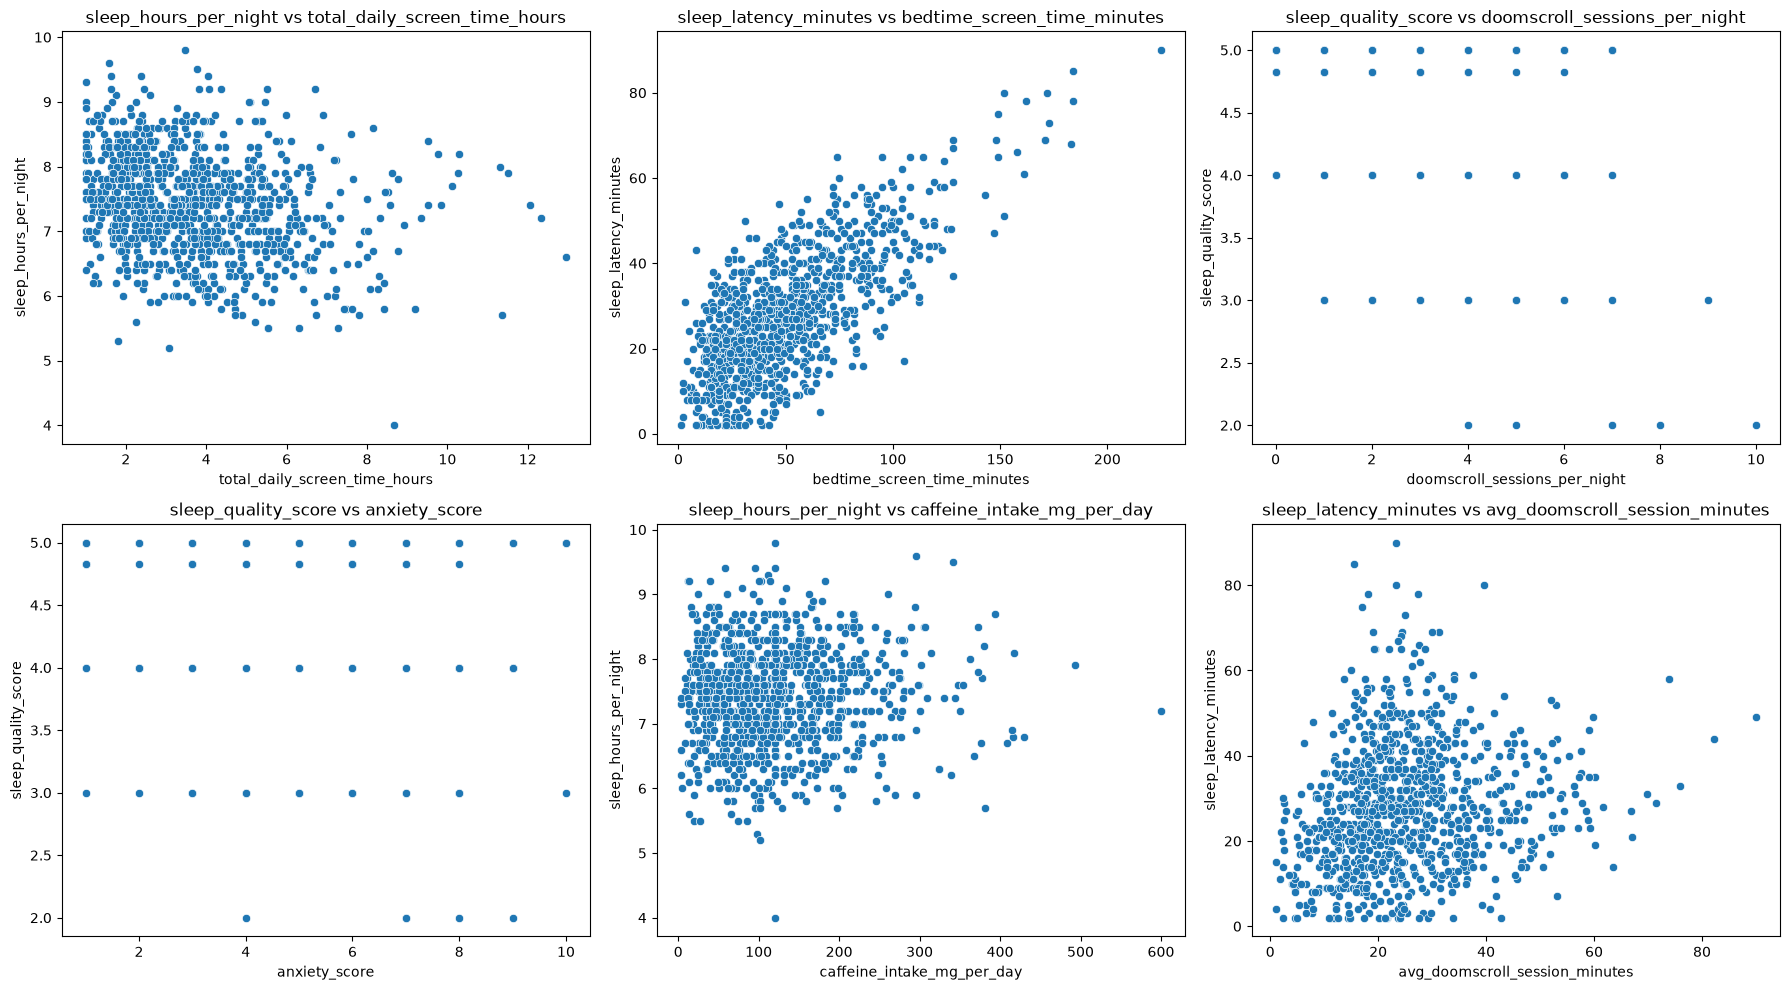

In [22]:
important_pairs = [
    ('total_daily_screen_time_hours', 'sleep_hours_per_night'),
    ('bedtime_screen_time_minutes', 'sleep_latency_minutes'),
    ('doomscroll_sessions_per_night', 'sleep_quality_score'),
    ('anxiety_score', 'sleep_quality_score'),
    ('caffeine_intake_mg_per_day', 'sleep_hours_per_night'),
    ('avg_doomscroll_session_minutes', 'sleep_latency_minutes')
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, (x, y) in enumerate(important_pairs):
    sns.scatterplot(data=df, x=x, y=y, ax=axes[i])
    axes[i].set_title(f"{y} vs {x}")
plt.tight_layout()
plt.show()

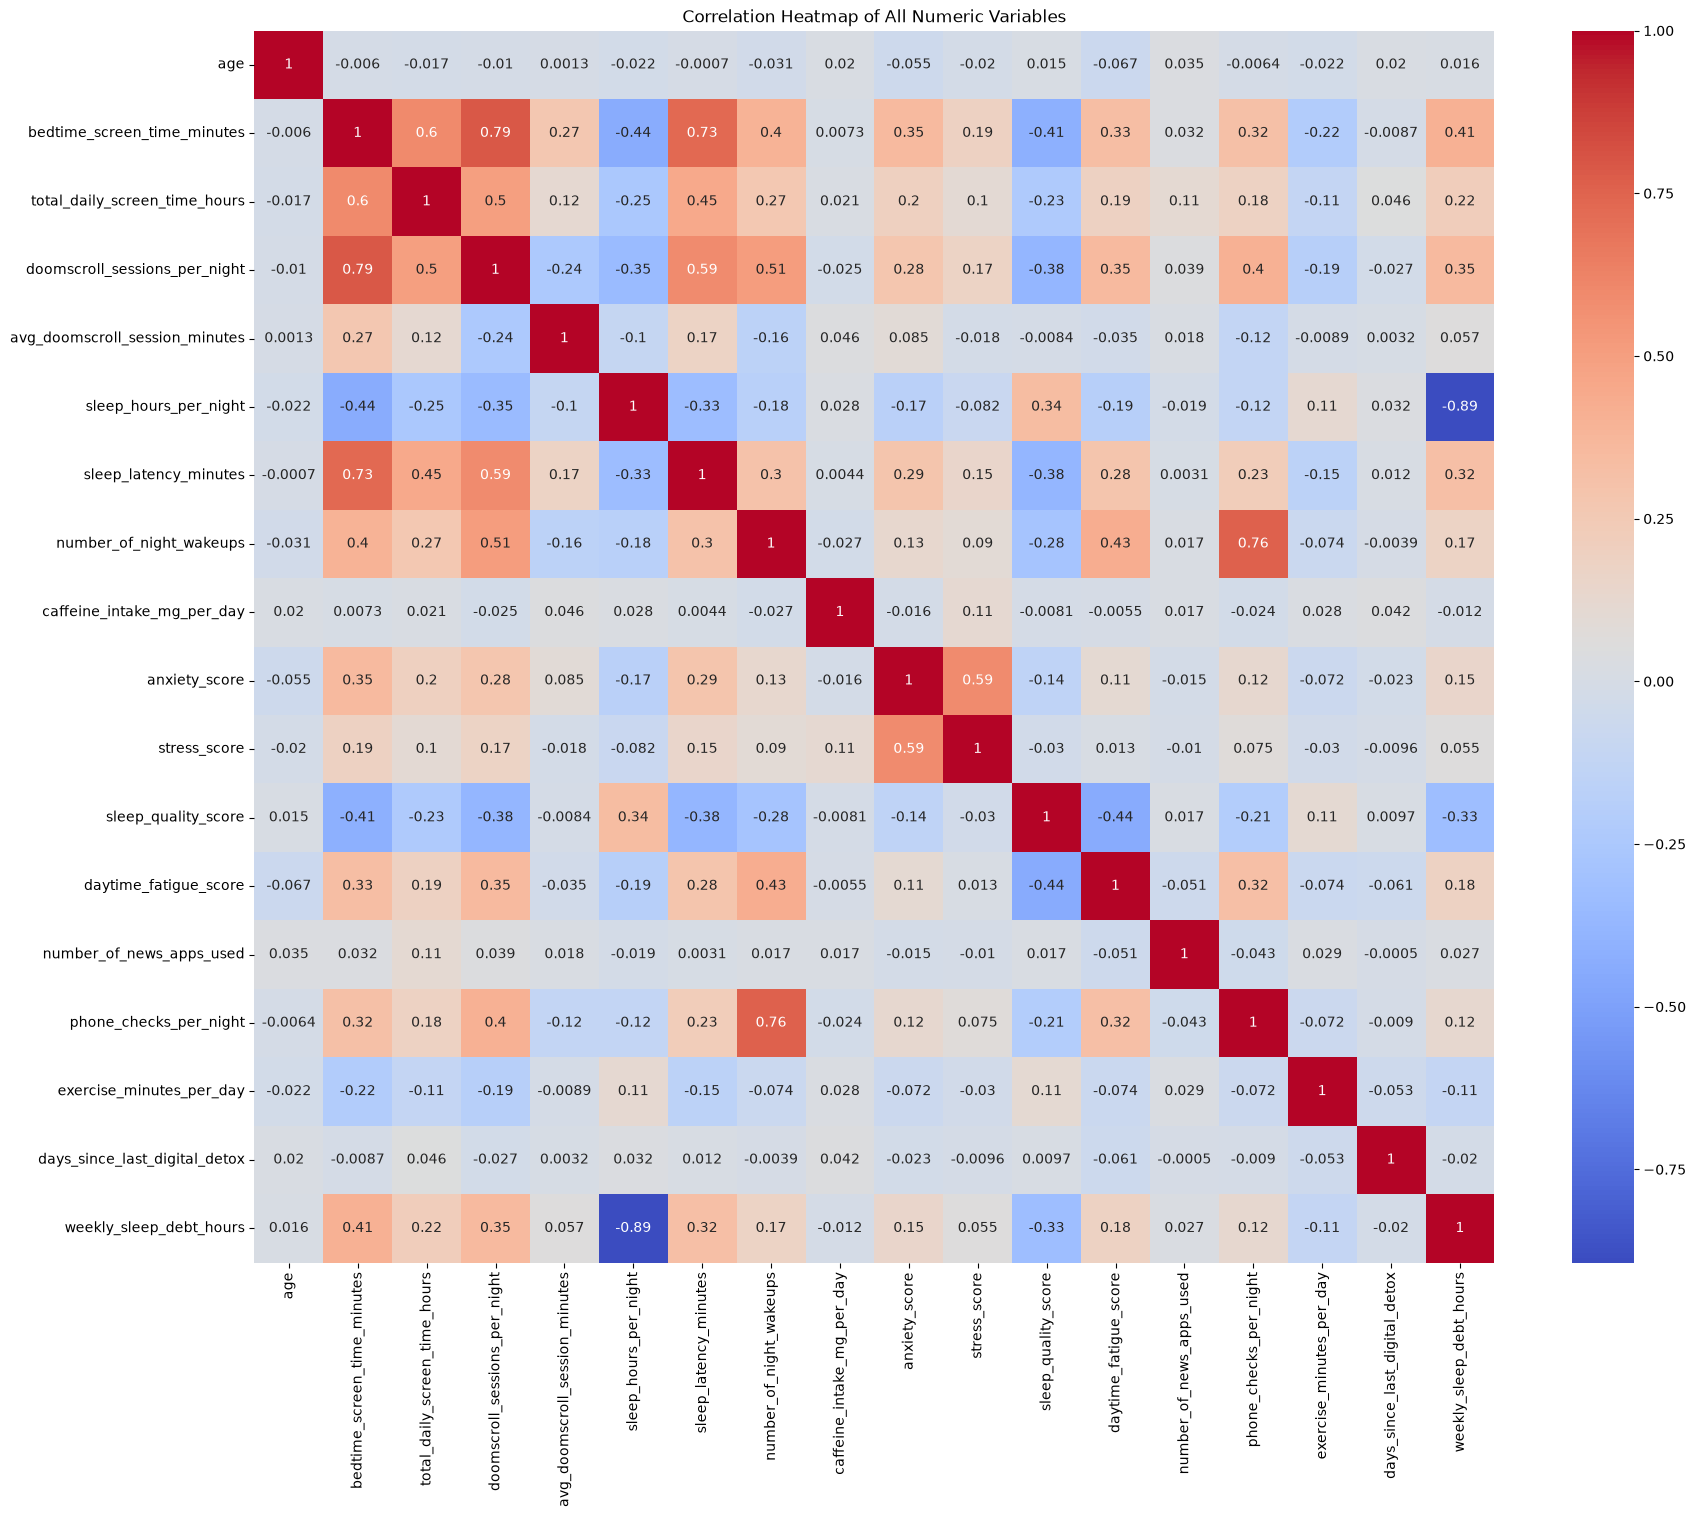

In [23]:

corr = df.corr(numeric_only=True)

plt.figure(figsize=(20, 16))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of All Numeric Variables")
plt.show()

In [24]:
corr_pairs = corr.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]
top_correlations = corr_pairs.head(5)
print("Top 5 Strongest Correlations:")
print(top_correlations)



Top 5 Strongest Correlations:
doomscroll_sessions_per_night  bedtime_screen_time_minutes      0.787583
bedtime_screen_time_minutes    doomscroll_sessions_per_night    0.787583
number_of_night_wakeups        phone_checks_per_night           0.758347
phone_checks_per_night         number_of_night_wakeups          0.758347
bedtime_screen_time_minutes    sleep_latency_minutes            0.729464
dtype: float64


#### Implications of the Top Correlations

1. **`doomscroll_sessions_per_night` & `bedtime_screen_time_minutes` (r ≈ 0.79)** — the strongest relationship in the dataset. If this reflects a real behavioral link (screen time before bed drives doomscrolling), a future model predicting sleep quality should treat these as one combined "pre-bed digital engagement" feature rather than two separate ones, to avoid multicollinearity.
2. **`number_of_night_wakeups` & `phone_checks_per_night` (r ≈ 0.76)** — night wakeups track closely with how often the phone is checked overnight, suggesting phone checks may be both a cause and a symptom of fragmented sleep.
3. **`sleep_latency_minutes` & `bedtime_screen_time_minutes` (r ≈ 0.73)** — more screen time right before bed is associated with taking longer to fall asleep, consistent with the well-documented effect of screen light/engagement delaying sleep onset.

None of these confirm causation — EDA only surfaces association. But they point to a small cluster of "pre-bed digital behavior" variables (bedtime screen time, doomscroll sessions, phone checks, sleep latency) that move together and would need feature-engineering attention (e.g. combining or regularizing) before modeling `sleep_quality_score`.

## Step 5: Commit the finished EDA notebook to GitHub with a clear commit message.

git init
git add .
git commit -m "Day 5: bivariate analysis, correlation heatmap, and full narrated EDA notebook"
git push






### Overall Summary & Next Steps

- **Data quality:** missing values were limited to 6 columns (numeric ones imputed with the mean, categorical ones with the mode) and are now fully resolved.
- **Distributions:** most digital-behavior variables (`bedtime_screen_time_minutes`, `caffeine_intake_mg_per_day`, `days_since_last_digital_detox`, `avg_doomscroll_session_minutes`) are right-skewed — a small group of heavy users pulls the mean up, so medians/robust scaling are preferable to means for these features going into a model.
- **Outliers:** flagged outliers (e.g. in `age` and `bedtime_screen_time_minutes`) look like genuine extreme-but-real respondents rather than data-entry errors, so they were kept rather than removed.
- **Relationships:** the strongest signals all cluster around *pre-bed digital engagement* (screen time, doomscrolling, phone checks) and its downstream effect on sleep latency and night wakeups — this is the feature group most likely to matter for predicting `sleep_quality_score` or `sleep_quality_category`.
- **Next step:** engineer a combined "pre-bed engagement" feature from the correlated group above, and treat `sleep_quality_category` as the likely classification target for a Week 3 model.
